# Single-Task Training: KSOL (Solubility)

Single-task Graph Transformer for **solubility (KSOL) prediction**.
This notebook trains and evaluates a model on the KSOL endpoint only.

In [ ]:
# ===========================
# Setup and Imports
# ===========================

import os
import sys
import math
import warnings
import logging
import random
from typing import List, Sequence, Optional
from functools import partial

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

import rdkit
from rdkit import RDLogger

import torch
from torch import nn
from torch.utils.data import DataLoader
from torch_geometric.data import Batch
import torch.nn.functional as F

from sklearn.metrics import mean_squared_error, r2_score
from scipy.stats import spearmanr, kendalltau

# Project imports
project_root = os.path.abspath("..")
if project_root not in sys.path:
    sys.path.insert(0, project_root)

from gt_pyg.data import (
    get_tensor_data,
    get_atom_feature_dim,
    get_bond_feature_dim,
)
from gt_pyg.nn import GraphTransformerNet

# Utils for log transform
src_path = os.path.abspath("src")
if src_path not in sys.path:
    sys.path.insert(0, src_path)
from utils import inverse_log_transform_assay_data

# Suppress RDKit warnings
RDLogger.logger().setLevel(RDLogger.CRITICAL)
warnings.filterwarnings("ignore")


def seed_everything(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


seed_everything(1928374650)

print(f"PyTorch: {torch.__version__}")
print(f"RDKit: {rdkit.__version__}")

In [ ]:
# ===========================
# Configuration
# ===========================

DEBUG = False

TRAIN_CSV = "data/train-set/expansion_log_data_train.csv"
TEST_CSV = "data/test-set/expansion_data_test_full_lb_flag.csv"
DELTA = 0.0
SINGLE_ENDPOINT = "LogS"

if DEBUG:
    BASE_BATCH_TRAIN = 32
    BASE_BATCH_EVAL = 64
    EPOCHS = 100
    NUM_TRAIN_SAMPLES = 200
    NUM_VAL_SAMPLES = 100
    HIDDEN_DIM = 64
    NUM_GT_LAYERS = 2
    NUM_HEADS = 4
    DROPOUT = 0.1
else:
    BASE_BATCH_TRAIN = 256
    BASE_BATCH_EVAL = 1024
    EPOCHS = 2000
    NUM_TRAIN_SAMPLES = None
    NUM_VAL_SAMPLES = None
    HIDDEN_DIM = 128
    NUM_GT_LAYERS = 4
    NUM_HEADS = 8
    DROPOUT = 0.3

DEVICE = "cpu"

if DEVICE:
    assert DEVICE in ("mps", "cuda", "cpu")
    device = torch.device(DEVICE)
else:
    device = torch.device("mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu")
    
NODE_DIM = get_atom_feature_dim()
EDGE_DIM = get_bond_feature_dim()

g_cpu = torch.Generator().manual_seed(1928374650)
g_gpu = torch.Generator(device=device).manual_seed(1928374650)

print(f"Mode: {'DEBUG' if DEBUG else 'PRODUCTION'}")
print(f"Device: {device}")
print(f"Node dim: {NODE_DIM}, Edge dim: {EDGE_DIM}")
print(f"Epochs: {EPOCHS}, Base batch size: {BASE_BATCH_TRAIN}")
print(f"Single endpoint: {SINGLE_ENDPOINT}")

In [5]:
# ===========================
# Load and Prepare Data
# ===========================

log_train_df = pd.read_csv(TRAIN_CSV)
ID_COLS = {"SMILES", "Molecule Name"}

ENDPOINTS = [SINGLE_ENDPOINT]
NUM_TASKS = 1

print(f"Total samples: {len(log_train_df)}")
print(f"Endpoint: {ENDPOINTS[0]}")

df = log_train_df.sample(frac=1, random_state=42).reset_index(drop=True)

if NUM_TRAIN_SAMPLES is not None and NUM_VAL_SAMPLES is not None:
    tr_df = df.iloc[:NUM_TRAIN_SAMPLES].copy()
    va_df = df.iloc[NUM_TRAIN_SAMPLES:NUM_TRAIN_SAMPLES + NUM_VAL_SAMPLES].copy()
else:
    n_train = int(0.8 * len(df))
    tr_df = df.iloc[:n_train].copy()
    va_df = df.iloc[n_train:].copy()

print(f"\nUsing: Train={len(tr_df)}, Val={len(va_df)}")

Total samples: 5326
Endpoint: LogS

Using: Train=4260, Val=1066


In [ ]:
# ===========================
# Build Datasets
# ===========================

def build_dataset(df, endpoints):
    smiles = df["SMILES"].tolist()
    Y = df[endpoints].values.tolist()
    return get_tensor_data(smiles, Y)

print("Building training dataset...")
tr_ds = build_dataset(tr_df, ENDPOINTS)

print("Building validation dataset...")
va_ds = build_dataset(va_df, ENDPOINTS)

print(f"\nTrain samples: {len(tr_ds)}, Val samples: {len(va_ds)}")

In [7]:
# ===========================
# Create DataLoaders
# ===========================

BATCH_TRAIN = BASE_BATCH_TRAIN
BATCH_EVAL = BASE_BATCH_EVAL


def collate_fn(data_list):
    return Batch.from_data_list(data_list)


tr_loader = DataLoader(tr_ds, batch_size=BATCH_TRAIN, shuffle=True, collate_fn=collate_fn)
va_loader = DataLoader(va_ds, batch_size=BATCH_EVAL, shuffle=False, collate_fn=collate_fn)

print(f"Train batches: {len(tr_loader)}, Val batches: {len(va_loader)}")

batch = next(iter(tr_loader))
print(f"\nSample batch:")
print(f"  Nodes: {batch.x.shape[0]}, Edges: {batch.edge_index.shape[1]}")

Train batches: 17, Val batches: 2

Sample batch:
  Nodes: 6967, Edges: 15654


In [ ]:
# ===========================
# Create Model
# ===========================

model = GraphTransformerNet(
    node_dim_in=NODE_DIM,
    edge_dim_in=EDGE_DIM,
    hidden_dim=HIDDEN_DIM,
    num_gt_layers=NUM_GT_LAYERS,
    num_heads=NUM_HEADS,
    dropout=DROPOUT,
    num_tasks=NUM_TASKS,
    norm="bn",
    gate=True,
    act="gelu",
    gt_aggregators=["sum", "mean"],
    aggregators=["sum", "mean", "max", "std"],
).to(device)

print(f"Model parameters: {model.num_parameters():,}")

In [9]:
# ===========================
# Loss Functions
# ===========================

@torch.no_grad()
def compute_task_scales(train_loader, num_tasks, eps=1e-8):
    ys = [[] for _ in range(num_tasks)]
    for batch in train_loader:
        y = batch.y.view(-1, num_tasks).detach().cpu().numpy()
        m = batch.y_mask.view(-1, num_tasks).detach().cpu().numpy().astype(bool)
        for t in range(num_tasks):
            yt = y[m[:, t], t]
            if yt.size:
                ys[t].append(yt)
    scales = []
    for t in range(num_tasks):
        if len(ys[t]) == 0:
            scales.append(1.0)
            continue
        v = np.concatenate(ys[t])
        v = v[np.isfinite(v)]
        if v.size < 3:
            scales.append(1.0)
            continue
        med = np.median(v)
        mad = np.median(np.abs(v - med))
        scales.append(float(max(mad, eps)))
    return torch.tensor(scales, dtype=torch.float32)


def _compute_example_weights(y, valid_label_mask, eps: float = 1e-8):
    device = y.device
    dtype = y.dtype
    w = torch.ones_like(y, dtype=dtype, device=device)
    w = torch.where(valid_label_mask, w, torch.zeros_like(w))
    return w


def masked_weighted_rae_loss(pred, y, mask, task_scale, eps=1e-8, clip_val=100.0):
    pred = torch.clamp(pred, -clip_val, clip_val)
    mask_f = mask.to(dtype=pred.dtype)
    valid_label = (mask_f > 0) & torch.isfinite(y)
    w = _compute_example_weights(y, valid_label)
    valid = valid_label & torch.isfinite(pred)
    w = torch.where(valid, w, torch.zeros_like(w))
    diff = torch.where(valid, pred - y, torch.zeros_like(pred))
    abs_err = diff.abs() / (task_scale.to(diff.device) + eps)
    weighted_err = abs_err * w
    sum_err_t = weighted_err.sum(dim=0)
    sum_w_t = w.sum(dim=0)
    sum_w_safe = sum_w_t.clamp_min(eps)
    mean_err_t = sum_err_t / sum_w_safe
    task_mask = sum_w_t > 0
    if task_mask.any():
        return mean_err_t[task_mask].mean()
    else:
        return pred.new_tensor(0.0)


def masked_weighted_huber_loss(
    pred, y, mask, delta=1.0, task_scale=None, clip_val=100.0, eps=1e-8,
):
    pred = torch.clamp(pred, -clip_val, clip_val)
    mask_f = mask.to(dtype=pred.dtype)
    valid_label = (mask_f > 0) & torch.isfinite(y)
    w = _compute_example_weights(y, valid_label)
    valid = valid_label & torch.isfinite(pred)
    w = torch.where(valid, w, torch.zeros_like(w))
    diff = torch.where(valid, pred - y, torch.zeros_like(pred))
    if task_scale is not None:
        diff = diff / (task_scale.to(diff.device) + eps)
    abs_diff = diff.abs()
    quad = torch.minimum(abs_diff, abs_diff.new_tensor(delta))
    loss = 0.5 * quad**2 + delta * (abs_diff - quad)
    weighted_loss = loss * w
    sum_t = weighted_loss.sum(dim=0)
    sum_w_t = w.sum(dim=0)
    sum_w_safe = sum_w_t.clamp_min(eps)
    mean_t = sum_t / sum_w_safe
    task_mask = sum_w_t > 0
    if task_mask.any():
        return mean_t[task_mask].mean()
    else:
        return pred.new_tensor(0.0)


def masked_weighted_corr_loss(pred, y, mask, eps=1e-8, clip_val=100.0):
    pred = torch.clamp(pred, -clip_val, clip_val)
    mask_f = mask.to(dtype=pred.dtype)
    valid_label = (mask_f > 0) & torch.isfinite(y)
    w = _compute_example_weights(y, valid_label)
    valid = valid_label & torch.isfinite(pred)
    w = torch.where(valid, w, torch.zeros_like(w))
    sum_w_t = w.sum(dim=0)
    sum_w_safe = sum_w_t.clamp_min(eps)
    pred_valid = torch.where(valid, pred, torch.zeros_like(pred))
    y_valid = torch.where(valid, y, torch.zeros_like(y))
    mean_p = (w * pred_valid).sum(dim=0) / sum_w_safe
    mean_y = (w * y_valid).sum(dim=0) / sum_w_safe
    p_c = torch.where(valid, pred_valid - mean_p.unsqueeze(0), torch.zeros_like(pred))
    y_c = torch.where(valid, y_valid - mean_y.unsqueeze(0), torch.zeros_like(y))
    cov = (w * p_c * y_c).sum(dim=0)
    var_p = (w * p_c * p_c).sum(dim=0)
    var_y = (w * y_c * y_c).sum(dim=0)
    std_p = torch.sqrt(var_p + eps)
    std_y = torch.sqrt(var_y + eps)
    corr = cov / (std_p * std_y + eps)
    per_task = 1.0 - corr
    task_mask = sum_w_t > 0
    if task_mask.any():
        return per_task[task_mask].mean()
    else:
        return pred.new_tensor(0.0)


def masked_weighted_kendall_rank_loss(
    pred, y, mask, num_pairs_per_task=512, tau_temp=1.0,
    clip_val=100.0, rng=None, eps=1e-8,
):
    pred = torch.clamp(pred, -clip_val, clip_val)
    B, T = pred.shape
    device = pred.device
    if rng is None:
        rng = torch.Generator(device=device).manual_seed(torch.initial_seed())
    mask_b = mask.bool()
    isfin_y = torch.isfinite(y)
    isfin_p = torch.isfinite(pred)
    valid_label = mask_b & isfin_y
    w_all = _compute_example_weights(y, valid_label)
    per_task_loss = []
    valid_counts = []
    for t in range(T):
        valid_t = mask_b[:, t] & isfin_y[:, t] & isfin_p[:, t]
        idx = torch.where(valid_t)[0]
        n = idx.numel()
        valid_counts.append(n)
        if n < 2:
            per_task_loss.append(pred.new_tensor(0.0))
            continue
        w_t_full = w_all[:, t]
        w_t = w_t_full[valid_t]
        max_pairs = n * (n - 1) // 2
        ii, jj = torch.triu_indices(n, n, offset=1, device=device)
        if max_pairs <= num_pairs_per_task:
            a, b = idx[ii], idx[jj]
            ia, ib = ii, jj
        else:
            probe = min(max_pairs, 8192)
            choose = torch.randperm(max_pairs, generator=rng, device=device)[:probe]
            ia_all, ib_all = ii[choose], jj[choose]
            ya = y[idx[ia_all], t]
            yb = y[idx[ib_all], t]
            ydiff = (ya - yb).abs()
            k = min(num_pairs_per_task, probe)
            topk = torch.topk(ydiff, k=k, largest=True).indices
            ia, ib = ia_all[topk], ib_all[topk]
            a, b = idx[ia], idx[ib]
        y_diff = y[a, t] - y[b, t]
        p_diff = pred[a, t] - pred[b, t]
        w_a = w_t[ia]
        w_b = w_t[ib]
        w_pair = 0.5 * (w_a + w_b)
        s = torch.sign(y_diff)
        non_tie = s != 0
        if non_tie.any():
            s = s[non_tie]
            p_diff_nt = p_diff[non_tie]
            w_pair_nt = w_pair[non_tie]
            loss_pairs = F.softplus(-s * p_diff_nt / tau_temp)
            weighted_loss_pairs = loss_pairs * w_pair_nt
            sum_w_pairs = w_pair_nt.sum().clamp_min(eps)
            per_task_loss.append(weighted_loss_pairs.sum() / sum_w_pairs)
        else:
            per_task_loss.append(pred.new_tensor(0.0))
    per_task_loss = torch.stack(per_task_loss, dim=0)
    cnt_raw = torch.tensor(valid_counts, dtype=pred.dtype, device=device)
    task_mask = cnt_raw > 1
    if task_mask.any():
        return per_task_loss[task_mask].mean()
    else:
        return pred.new_tensor(0.0)


def masked_r2_style_loss(pred, y, mask, eps=1e-8, clip_val=100.0):
    pred = torch.clamp(pred, -clip_val, clip_val)
    mask_b = mask.bool()
    isfin_y = torch.isfinite(y)
    isfin_p = torch.isfinite(pred)
    valid = mask_b & isfin_y & isfin_p
    if not valid.any():
        return pred.new_tensor(0.0)
    valid_counts = valid.sum(dim=0)
    task_has_data = valid_counts > 1
    if not task_has_data.any():
        return pred.new_tensor(0.0)
    pred_valid = torch.where(valid, pred, torch.zeros_like(pred))
    y_valid = torch.where(valid, y, torch.zeros_like(y))
    sum_y_t = y_valid.sum(dim=0)
    mean_y_t = sum_y_t / (valid_counts + eps)
    y_centered = torch.where(valid, y - mean_y_t.unsqueeze(0), torch.zeros_like(y))
    diff = pred_valid - y_valid
    sse_t = (diff**2).sum(dim=0)
    var_t = (y_centered**2).sum(dim=0)
    denom_ok = var_t > eps
    good_tasks = task_has_data & denom_ok
    if not good_tasks.any():
        return pred.new_tensor(0.0)
    l_t = sse_t / (var_t + eps)
    return l_t[good_tasks].mean()


def custom_loss(
    pred, y, mask, *,
    w_rae=1.0, w_huber=1.0, w_corr=0.5, w_tau=0.5, w_r2=0.1,
    huber_delta=1.0, clip_val=100.0, tau_temp=1.0, rank_pairs=512,
    task_scale=None, rng=None, **kwargs,
):
    pred = torch.clamp(pred, -clip_val, clip_val)
    L_rae = (
        masked_weighted_rae_loss(pred, y, mask, task_scale=task_scale, clip_val=clip_val)
        if w_rae > 0 and task_scale is not None else pred.new_tensor(0.0)
    )
    L_huber = (
        masked_weighted_huber_loss(pred, y, mask, delta=huber_delta, task_scale=task_scale, clip_val=clip_val)
        if w_huber > 0 else pred.new_tensor(0.0)
    )
    L_corr = (
        masked_weighted_corr_loss(pred, y, mask, clip_val=clip_val)
        if w_corr > 0 else pred.new_tensor(0.0)
    )
    L_tau = (
        masked_weighted_kendall_rank_loss(
            pred, y, mask, num_pairs_per_task=rank_pairs,
            tau_temp=tau_temp, clip_val=clip_val, rng=rng,
        )
        if w_tau > 0 else pred.new_tensor(0.0)
    )
    L_r2 = (
        masked_r2_style_loss(pred, y, mask, clip_val=clip_val)
        if w_r2 > 0 else pred.new_tensor(0.0)
    )
    return w_rae * L_rae + w_huber * L_huber + w_corr * L_corr + w_tau * L_tau + w_r2 * L_r2

In [10]:
# ===========================
# Metrics Functions
# ===========================

def _safe_metrics(y_true, y_pred):
    y_true = np.asarray(y_true).ravel()
    y_pred = np.asarray(y_pred).ravel()
    mse = mean_squared_error(y_true, y_pred)
    mae = float(np.mean(np.abs(y_true - y_pred)))
    r2 = r2_score(y_true, y_pred) if len(np.unique(y_true)) > 1 else np.nan
    rho, _ = spearmanr(y_true, y_pred)
    tau, _ = kendalltau(y_true, y_pred)
    return {
        "mse": float(mse), "mae": float(mae), "r2": float(r2),
        "spearman_rho": float(rho), "kendall_tau": float(tau),
    }


def _official_metrics(y_true_1d, y_pred_1d):
    y = np.asarray(y_true_1d).ravel()
    p = np.asarray(y_pred_1d).ravel()
    m = np.isfinite(y) & np.isfinite(p)
    y, p = y[m], p[m]
    if y.size == 0:
        return {
            "MAE": np.nan, "RAE": np.nan, "R2": np.nan,
            "Spearman R": np.nan, "Kendall's Tau": np.nan,
        }
    mae = float(np.mean(np.abs(y - p)))
    denom = np.mean(np.abs(y - np.mean(y)))
    rae = float(mae / denom) if denom and np.isfinite(denom) and denom > 0 else np.nan
    r2 = float(r2_score(y, p)) if (np.nanstd(y) > 0) else np.nan
    if np.nanstd(p) < 1e-4:
        spr, ktau = np.nan, np.nan
    else:
        spr = float(spearmanr(y, p)[0])
        ktau = float(kendalltau(y, p)[0])
    return {"MAE": mae, "RAE": rae, "R2": r2, "Spearman R": spr, "Kendall's Tau": ktau}


def per_task_metrics(y_true_2d, y_pred_2d, mask_2d, names):
    N, T = y_true_2d.shape
    out = {}
    for t, name in enumerate(names):
        m = mask_2d[:, t].astype(bool)
        if m.sum() < 3:
            out[name] = {
                "mse": np.nan, "mae": np.nan, "r2": np.nan,
                "spearman_rho": np.nan, "kendall_tau": np.nan, "n": int(m.sum()),
            }
            continue
        mt = _safe_metrics(y_true_2d[m, t], y_pred_2d[m, t])
        mt["n"] = int(m.sum())
        out[name] = mt
    return out


def macro_official_avg(metrics_dict):
    keys = ["MAE", "RAE", "R2", "Spearman R", "Kendall's Tau"]
    vals = {k: [] for k in keys}
    for ep, md in metrics_dict.items():
        if ep == "Average":
            continue
        for k in keys:
            vals[k].append(md.get(k, np.nan))
    return {k: float(np.nanmean(v)) if len(v) else np.nan for k, v in vals.items()}

In [11]:
# ===========================
# Forward and Training Functions
# ===========================

def forward_batch(model, batch):
    batch = batch.to(device)
    pred, log_var = model(batch.x, batch.edge_index, batch.edge_attr, batch)
    return pred, log_var


def train_epoch(model, loader, optimizer, task_scale, rng):
    model.train()
    total_loss = 0
    num_batches = 0
    for batch in loader:
        optimizer.zero_grad()
        pred, log_var = forward_batch(model, batch)
        y = batch.y.view(-1, NUM_TASKS).to(device)
        mask = batch.y_mask.view(-1, NUM_TASKS).to(device)
        valid_mask = mask * (~torch.isnan(y)).float()
        loss = custom_loss(
            pred, y, valid_mask,
            w_rae=1.0, w_huber=0.25, w_corr=0.25, w_tau=0.1, w_r2=0.1,
            huber_delta=0.5, tau_temp=2.0, task_scale=task_scale, rng=rng,
        )
        if torch.isnan(loss):
            print("  Warning: NaN loss detected, skipping batch")
            continue
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
        optimizer.step()
        total_loss += loss.item()
        num_batches += 1
    return total_loss / max(num_batches, 1)


@torch.no_grad()
def evaluate(model, loader, task_scale, endpoints):
    model.eval()
    total_loss = 0
    num_batches = 0
    all_preds, all_targets, all_masks = [], [], []
    for batch in loader:
        pred, log_var = forward_batch(model, batch)
        y = batch.y.view(-1, NUM_TASKS).to(device)
        mask = batch.y_mask.view(-1, NUM_TASKS).to(device)
        valid_mask = mask * (~torch.isnan(y)).float()
        loss = custom_loss(pred, y, valid_mask, task_scale=task_scale, rng=None)
        if not torch.isnan(loss):
            total_loss += loss.item()
            num_batches += 1
        all_preds.append(pred.cpu())
        all_targets.append(y.cpu())
        all_masks.append(valid_mask.cpu())
    preds = torch.cat(all_preds).numpy()
    targets = torch.cat(all_targets).numpy()
    masks = torch.cat(all_masks).numpy()
    avg_loss = total_loss / max(num_batches, 1)
    task_metrics = per_task_metrics(targets, preds, masks, endpoints)
    official_keys = ["MAE", "RAE", "R2", "Spearman R", "Kendall's Tau"]
    per_endpoint_official = {k: [] for k in official_keys}
    for i, ep in enumerate(endpoints):
        m = masks[:, i].astype(bool)
        official = (
            _official_metrics(targets[m, i], preds[m, i])
            if m.sum() > 0
            else {k: np.nan for k in official_keys}
        )
        for k in official_keys:
            per_endpoint_official[k].append(official[k])
        if ep in task_metrics:
            task_metrics[ep].update(official)
    avg_metrics = {k: float(np.nanmean(per_endpoint_official[k])) for k in official_keys}
    task_metrics["Average"] = avg_metrics
    return avg_loss, task_metrics, preds, targets, masks

In [12]:
# ===========================
# Compute Task Scales
# ===========================

print("Computing per-task scales (MAD) from training data...")
task_scale = compute_task_scales(tr_loader, NUM_TASKS)
print(f"Task scales: {task_scale.tolist()}")

Computing per-task scales (MAD) from training data...
Task scales: [0.31361913681030273]


In [13]:
# ===========================
# Setup Optimizer and Scheduler
# ===========================

base_lr = 1e-3
min_lr = base_lr / 100.0
optimizer = torch.optim.AdamW(model.parameters(), lr=base_lr, weight_decay=1e-5)

T_max = min(500, EPOCHS)
warmup_epochs = min(25, T_max)


def lr_lambda(epoch):
    if epoch < warmup_epochs:
        return (epoch + 1) / warmup_epochs
    progress = (epoch - warmup_epochs) / max(1, T_max - warmup_epochs)
    cosine = 0.5 * (1 + math.cos(math.pi * progress))
    return min_lr / base_lr + (1 - min_lr / base_lr) * cosine


scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

print(f"Optimizer: AdamW, base_lr={base_lr}, min_lr={min_lr}")
print(f"Scheduler: warmup={warmup_epochs} epochs, then cosine decay")

Optimizer: AdamW, base_lr=0.001, min_lr=1e-05
Scheduler: warmup=25 epochs, then cosine decay


In [14]:
# ===========================
# Train
# ===========================

train_losses, val_losses = [], []
train_raes, val_raes = [], []
train_r2s, val_r2s = [], []
train_kendalls, val_kendalls = [], []
KT_KEY = "Kendall's Tau"

best_val_rae = float("inf")
best_state = None
best_epoch = 0

train_mins = tr_df[ENDPOINTS].min().to_dict()
train_maxs = tr_df[ENDPOINTS].max().to_dict()

best_state_per_ep = {}
best_epoch_per_ep = {}
best_nma_per_ep = {}
for ep_name in ENDPOINTS:
    best_nma_per_ep[ep_name] = float("inf")
    best_epoch_per_ep[ep_name] = 0
    best_state_per_ep[ep_name] = None

print(f"Training for {EPOCHS} epochs...")

for epoch in range(1, EPOCHS + 1):
    tr_loader = DataLoader(
        tr_ds, batch_size=BASE_BATCH_TRAIN, shuffle=True, collate_fn=collate_fn,
    )
    va_loader = DataLoader(
        va_ds, batch_size=BASE_BATCH_EVAL, shuffle=False, collate_fn=collate_fn,
    )

    train_loss = train_epoch(model, tr_loader, optimizer, task_scale, g_gpu)
    val_loss, val_metrics, _, _, _ = evaluate(model, va_loader, task_scale, ENDPOINTS)

    current_lr = optimizer.param_groups[0]["lr"]
    scheduler.step()

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    avg_val = val_metrics["Average"]
    val_raes.append(avg_val["RAE"])
    val_r2s.append(avg_val["R2"])
    val_kendalls.append(avg_val[KT_KEY])

    if avg_val["RAE"] < best_val_rae:
        best_val_rae = avg_val["RAE"]
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        best_epoch = epoch

    for ep_name in ENDPOINTS:
        ep_metrics = val_metrics.get(ep_name, {})
        ep_mae = ep_metrics.get("MAE", np.inf)
        tr_min = train_mins.get(ep_name, np.nan)
        tr_max = train_maxs.get(ep_name, np.nan)
        if (
            np.isfinite(ep_mae) and np.isfinite(tr_min)
            and np.isfinite(tr_max) and (tr_max > tr_min)
        ):
            ep_nma = float(ep_mae / (tr_max - tr_min))
        else:
            ep_nma = np.inf
        if ep_nma < best_nma_per_ep[ep_name]:
            best_nma_per_ep[ep_name] = ep_nma
            best_epoch_per_ep[ep_name] = epoch
            best_state_per_ep[ep_name] = {
                k: v.cpu().clone() for k, v in model.state_dict().items()
            }

    if epoch == 1 or epoch % 5 == 0 or epoch == EPOCHS:
        _, train_metrics, _, _, _ = evaluate(model, tr_loader, task_scale, ENDPOINTS)
        tr_off = macro_official_avg(train_metrics)
        va_off = macro_official_avg(val_metrics)
        train_raes.append(tr_off["RAE"])
        train_r2s.append(tr_off["R2"])
        train_kendalls.append(tr_off[KT_KEY])
        print(
            f"[Ep {epoch:03d}] LR={current_lr:.1e} | "
            f"Train: MAE={tr_off['MAE']:.3f}, RAE={tr_off['RAE']:.3f}, "
            f"R2={tr_off['R2']:.3f}, rho={tr_off['Spearman R']:.3f}, "
            f"tau={tr_off[KT_KEY]:.3f} | "
            f"Val: MAE={va_off['MAE']:.3f}, RAE={va_off['RAE']:.3f}, "
            f"R2={va_off['R2']:.3f}, rho={va_off['Spearman R']:.3f}, "
            f"tau={va_off[KT_KEY]:.3f}"
        )

print(f"\nBest validation RAE: {best_val_rae:.4f} at epoch {best_epoch}")

Training for 2000 epochs...
[Ep 001] LR=4.0e-05 | Train: MAE=2.972, RAE=5.051, R2=-17.699, rho=-0.180, tau=-0.127 | Val: MAE=3.029, RAE=4.851, R2=-17.078, rho=-0.229, tau=-0.162
[Ep 005] LR=2.0e-04 | Train: MAE=2.374, RAE=4.036, R2=-13.102, rho=-0.075, tau=-0.050 | Val: MAE=2.377, RAE=3.807, R2=-11.951, rho=-0.141, tau=-0.093
[Ep 010] LR=4.0e-04 | Train: MAE=1.804, RAE=3.066, R2=-6.734, rho=0.349, tau=0.249 | Val: MAE=1.776, RAE=2.845, R2=-5.890, rho=0.366, tau=0.266
[Ep 015] LR=6.0e-04 | Train: MAE=0.794, RAE=1.350, R2=-0.683, rho=0.373, tau=0.269 | Val: MAE=0.780, RAE=1.249, R2=-0.493, rho=0.388, tau=0.280
[Ep 020] LR=8.0e-04 | Train: MAE=1.053, RAE=1.789, R2=-1.752, rho=0.386, tau=0.286 | Val: MAE=1.026, RAE=1.643, R2=-1.488, rho=0.390, tau=0.292
[Ep 025] LR=1.0e-03 | Train: MAE=0.532, RAE=0.905, R2=0.004, rho=0.435, tau=0.320 | Val: MAE=0.536, RAE=0.858, R2=0.062, rho=0.452, tau=0.332
[Ep 030] LR=1.0e-03 | Train: MAE=0.661, RAE=1.124, R2=-0.334, rho=0.449, tau=0.335 | Val: MAE=0.67

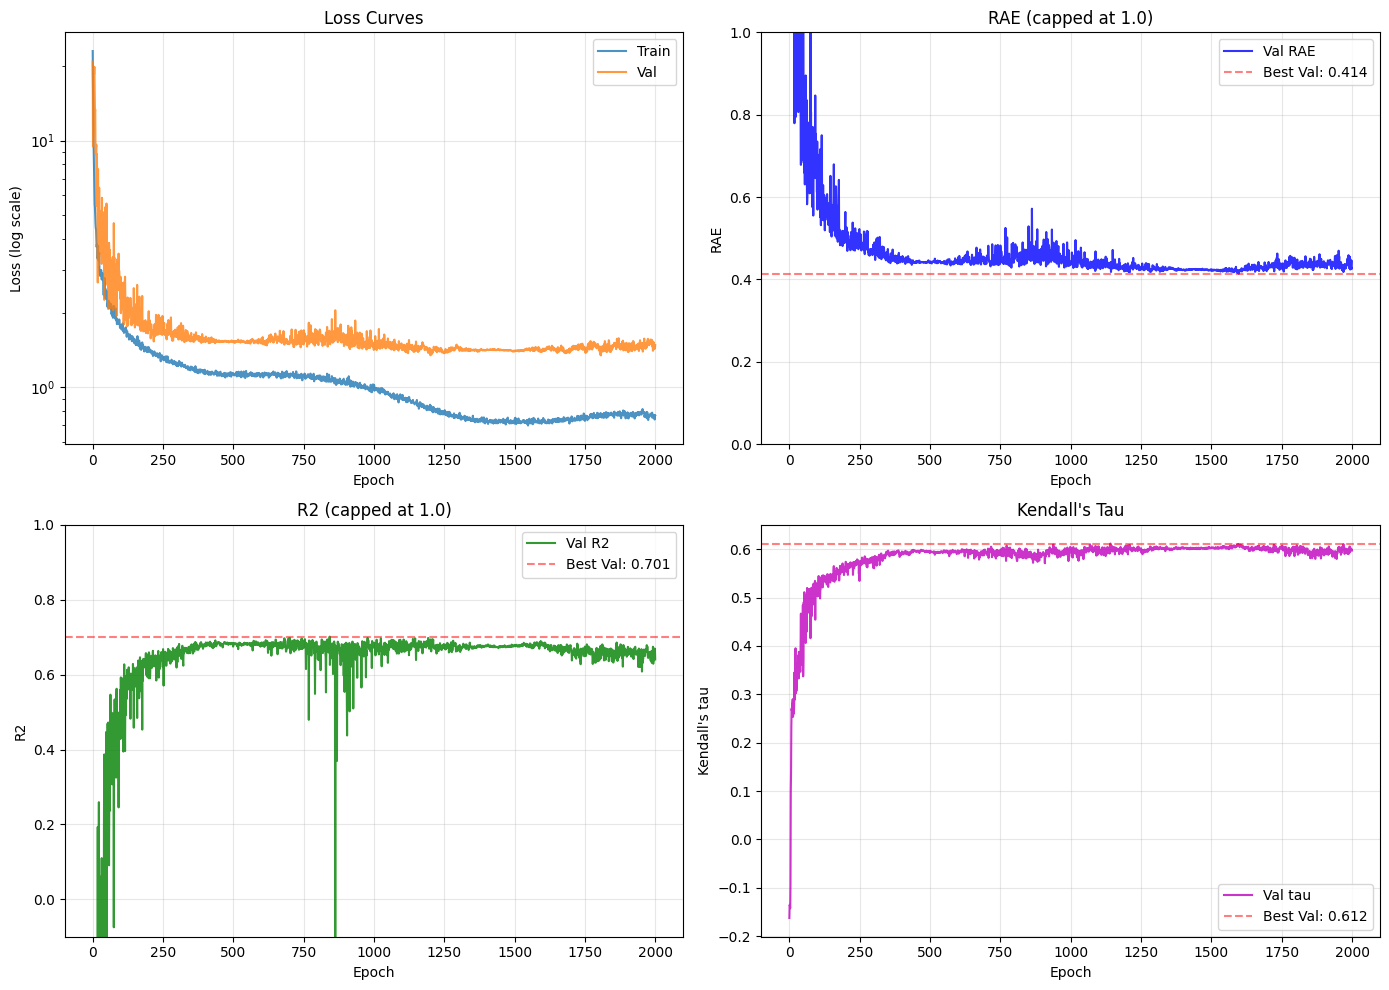

In [15]:
# ===========================
# Plot Training Curves
# ===========================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

ax = axes[0, 0]
ax.semilogy(train_losses, label="Train", alpha=0.8)
ax.semilogy(val_losses, label="Val", alpha=0.8)
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss (log scale)")
ax.set_title("Loss Curves")
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[0, 1]
ax.plot(val_raes, "b-", alpha=0.8, label="Val RAE")
ax.set_ylim(0, 1.0)
ax.axhline(min(val_raes), color="r", linestyle="--", alpha=0.5,
           label=f"Best Val: {min(val_raes):.3f}")
ax.set_xlabel("Epoch")
ax.set_ylabel("RAE")
ax.set_title("RAE (capped at 1.0)")
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1, 0]
ax.plot(val_r2s, "g-", alpha=0.8, label="Val R2")
ax.set_ylim(-0.1, 1.0)
ax.axhline(max(val_r2s), color="r", linestyle="--", alpha=0.5,
           label=f"Best Val: {max(val_r2s):.3f}")
ax.set_xlabel("Epoch")
ax.set_ylabel("R2")
ax.set_title("R2 (capped at 1.0)")
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1, 1]
ax.plot(val_kendalls, "m-", alpha=0.8, label="Val tau")
ax.axhline(max(val_kendalls), color="r", linestyle="--", alpha=0.5,
           label=f"Best Val: {max(val_kendalls):.3f}")
ax.set_xlabel("Epoch")
ax.set_ylabel("Kendall's tau")
ax.set_title("Kendall's Tau")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [16]:
# ===========================
# Final Evaluation with Best Models
# ===========================

if best_state is not None:
    model.load_state_dict(best_state)
    print(f"Loaded global best model from epoch {best_epoch}")

_, final_metrics_global, final_preds, final_targets, final_masks = evaluate(
    model, va_loader, task_scale, ENDPOINTS,
)

print("\n" + "=" * 70)
print("FINAL VALIDATION METRICS")
print("=" * 70)

print(
    f"\n{'Endpoint':<25} {'MAE':>8} {'RAE':>8} {'R2':>8} "
    f"{'rho':>8} {'tau':>8}"
)
print("-" * 70)

for ep in ENDPOINTS:
    m = final_metrics_global.get(ep, {})
    tau_val = m.get(KT_KEY, np.nan)
    rho_val = m.get("Spearman R", np.nan)
    print(
        f"{ep:<25} {m.get('MAE', np.nan):>8.3f} {m.get('RAE', np.nan):>8.3f} "
        f"{m.get('R2', np.nan):>8.3f} {rho_val:>8.3f} {tau_val:>8.3f}"
    )

Loaded global best model from epoch 1598

FINAL VALIDATION METRICS

Endpoint                       MAE      RAE       R2      rho      tau
----------------------------------------------------------------------
LogS                         0.258    0.414    0.684    0.792    0.610


In [ ]:
# ===========================
# Summary
# ===========================

print("=" * 60)
print("TRAINING COMPLETE — KSOL (Solubility)")
print("=" * 60)
print(f"\nModel: GraphTransformerNet (Single-Task)")
print(f"  Hidden dim: {HIDDEN_DIM}")
print(f"  GT layers: {NUM_GT_LAYERS}")
print(f"  Heads: {NUM_HEADS}")
print(f"  Parameters: {model.num_parameters():,}")
print(f"\nEndpoint: KSOL (trained on LogS = log10((KSOL+1)*1e-6))")
print(f"\nTraining:")
print(f"  Epochs: {EPOCHS}")
print(f"  Train samples: {len(tr_df)}")
print(f"  Val samples: {len(va_df)}")
print(f"\nBest Results (epoch {best_epoch}):")
print(f"  Val RAE: {best_val_rae:.4f}")
print(f"  Val R2: {max(val_r2s):.4f}")
print(f"  Val Kendall tau: {max(val_kendalls):.4f}")

In [ ]:
# ===========================
# Generate Submission
# ===========================

if best_state is not None:
    model.load_state_dict(best_state)

test_df = pd.read_csv(TEST_CSV)
test_smiles = test_df["SMILES"].tolist()

print("Building test dataset...")
test_ds = get_tensor_data(
    test_smiles,
    [[np.nan] * NUM_TASKS for _ in range(len(test_smiles))],
)

test_loader = DataLoader(test_ds, batch_size=BASE_BATCH_EVAL, shuffle=False, collate_fn=collate_fn)

model.eval()
test_preds = []
with torch.no_grad():
    for batch in test_loader:
        pred, _ = forward_batch(model, batch)
        test_preds.append(pred.detach().cpu().numpy())
test_preds = np.vstack(test_preds)

# Clip to training range
preds_df = test_df[["SMILES", "Molecule Name"]].copy()
for i, ep in enumerate(ENDPOINTS):
    col = test_preds[:, i]
    vmin = train_mins[ep]
    vmax = train_maxs[ep]
    v_range = vmax - vmin
    col = np.clip(col, vmin - DELTA * v_range, vmax + DELTA * v_range)
    preds_df[ep] = col

# Inverse transform and save
output_df, _ = inverse_log_transform_assay_data(preds_df)
out_path = "data/submissions/submission_ksol_st.csv"
output_df.to_csv(out_path, index=False)
print(f"Saved: {out_path}")
print(f"Test predictions shape: {test_preds.shape}")
print(output_df.head())